In [1]:
pip install tensorflow

In [2]:
# Step 1: Import libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [3]:
# Step 2: Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 307s 2us/step


In [4]:
# Step 3: Normalize data
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
# Step 4: Define class names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat',
               'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


In [6]:
# Step 5: Build CNN model
model = models.Sequential()

In [7]:
# Convolution Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu',
                        input_shape=(32,32,3)))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Pooling Layer
model.add(layers.MaxPooling2D((2,2)))

In [9]:
# Convolution Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))

In [10]:
# Pooling Layer
model.add(layers.MaxPooling2D((2,2)))

In [11]:
# Flatten Layer
model.add(layers.Flatten())

In [12]:
# Dense Layer
model.add(layers.Dense(64, activation='relu'))

In [13]:
# Output Layer
model.add(layers.Dense(10, activation='softmax'))

In [14]:
# Step 6: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [15]:
# Step 7: Train model
history = model.fit(x_train, y_train,
                    epochs=5,
                    validation_data=(x_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.4680 - loss: 1.4751 - val_accuracy: 0.5676 - val_loss: 1.2182
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.6025 - loss: 1.1315 - val_accuracy: 0.6239 - val_loss: 1.0768
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 43ms/step - accuracy: 0.6485 - loss: 1.0076 - val_accuracy: 0.6212 - val_loss: 1.0895
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 41ms/step - accuracy: 0.6760 - loss: 0.9339 - val_accuracy: 0.6576 - val_loss: 0.9908
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.6987 - loss: 0.8777 - val_accuracy: 0.6723 - val_loss: 0.9509


In [17]:
# Step 8: Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6723 - loss: 0.9509
Test Accuracy: 0.6722999811172485


In [26]:
# Step 9: Predict one image
prediction = model.predict(x_test)

print("Predicted Class:",
      class_names[prediction[7].argmax()])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
Predicted Class: Frog


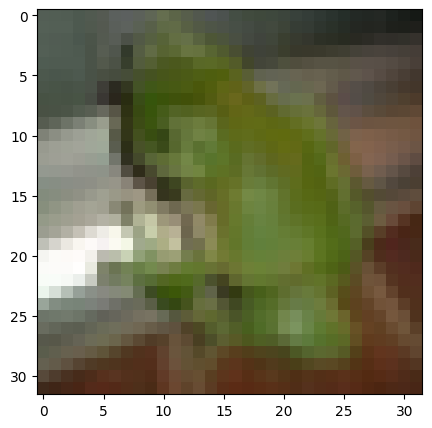

In [27]:
plt.figure(figsize=(5,5))
plt.imshow(x_test[7])
plt.show()